# <center>Class 17: Probabilities & Classification </center>

In [1]:
import os
import datetime
import pandas as pd
import numpy as np
import sys
import patsy
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
import sklearn.metrics as metrics
from sklearn.metrics import brier_score_loss, roc_curve, auc, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

### Define helper functions

In [2]:
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance=metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred) 
    mse=metrics.mean_squared_error(y_true, y_pred) 
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print('explained_variance: ', round(explained_variance,4))    
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))
    
def create_coef_matrix(X, model):
    coef_matrix = pd.concat(
        [pd.DataFrame(X.columns),pd.DataFrame(model.coef_.flatten())], axis = 1
    )
    coef_matrix.columns = ['variable', 'coefficient']
    coef_matrix.iloc[-1] = ['Intercept', model.intercept_.flatten()[0]]
    return coef_matrix

def cv_summary(lambdas, C_values, model):
    d = {'lambdas': lambdas, 
         'C_values': C_values, 
         'mean_cv_score': model.scores_[1].mean(axis = 0)}
    return(pd.DataFrame(data=d))

"""def create_roc_plot(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    all_coords = pd.DataFrame({
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds
    })
    
    plot = ggplot(all_coords, aes(x = 'fpr', y = 'tpr')) \
        + geom_line(color=color[0], size = 0.7) \
        + geom_area(position = 'identity', fill = 'mediumaquamarine', alpha = 0.3) \
        + xlab("False Positive Rate (1-Specifity)") \
        + ylab("True Positive Rate (Sensitivity)") \
        + geom_abline(intercept = 0, slope = 1,  linetype = "dotted", color = "black") \
        + scale_y_continuous(limits = (0, 1), breaks = seq(0, 1, .1), expand = (0, 0.01)) \
        + scale_x_continuous(limits = (0, 1), breaks = seq(0, 1, .1), expand = (0.01, 0)) \
        + theme_bw()
    return(plot)
"""

def create_roc_plot(y_true, y_pred):
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Plot ROC curve line
    ax.plot(fpr, tpr, color='k', linewidth=0.7)
    
    # Fill area under curve
    ax.fill_between(fpr, tpr, alpha=0.3, color='white')
    
    # Add diagonal dotted line
    ax.plot([0, 1], [0, 1], linestyle=':', color='black')
    
    # Set axis labels
    ax.set_xlabel('False Positive Rate (1-Specificity)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    
    # Set axis limits and ticks
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    
    # Style similar to theme_bw()
    ax.grid(True, linestyle='-', alpha=0.2)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('black')
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax


def sigmoid_array(x):
    return(1 / (1 + np.exp(-x)))

def generate_fold_prediction(model, X, fold, param_index):
    fold_coef = model.coefs_paths_[1][fold,param_index,:]
    return(sigmoid_array(np.dot(X, np.transpose(fold_coef)[:-1]) +  np.transpose(fold_coef)[-1]))

"""def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    all_coords_copy = all_coords.copy()
    all_coords_copy['loss'] = (all_coords_copy.false_pos*FP + all_coords_copy.false_neg*FN)/all_coords_copy.n
    
    t = optimal_threshold
    l = curr_exp_loss
    
    plot = ggplot(all_coords_copy, aes(x = 'thresholds', y = 'loss')) + \
        geom_line(color=color[0], size=0.7) + \
        scale_x_continuous(breaks = seq(0, 1.1, by = 0.1)) + \
        coord_cartesian(xlim=(0,1))+ \
        geom_vline(xintercept = t , color = color[0] ) + \
        annotate(geom = "text", x = t - 0.01, y= max(all_coords_copy.loss) - 0.4,
                 label="best threshold: " + str(round(t,2)),
                 colour=color[1], angle=90, size = 7) +\
        annotate(geom = "text", x = t + 0.06, y= l,\
                 label= str(round(l, 2)), size = 7) +\
        theme_bw()
    return(plot)"""

def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    # Create copy and calculate loss
    all_coords_copy = all_coords.copy()
    all_coords_copy['loss'] = (all_coords_copy.false_pos*FP + all_coords_copy.false_neg*FN)/all_coords_copy.n
    
    t = optimal_threshold
    l = curr_exp_loss

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6, 5))

    # Plot loss line
    ax.plot(all_coords_copy['thresholds'], all_coords_copy['loss'], 
            color= 'k', linewidth=0.7)

    # Add vertical line at optimal threshold
    ax.axvline(x=t, color = 'k')

    # Add annotations
    ax.text(t - 0.04, max(all_coords_copy.loss) - 0.5,
            f"best threshold: {t:.2f}", 
            color = 'k', 
            rotation=90, 
            fontsize = 9)
    
    ax.text(t + 0.06, l,
            f"{l:.2f}",
            fontsize = 9)

    # Set x-axis ticks and limits
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xlim(0, 1)

    # Style similar to theme_bw()
    ax.grid(True, linestyle='-', alpha=0.2)
    ax.set_facecolor('white')
    ax.set_xlabel('threshold')
    ax.set_ylabel('loss')
    for spine in ax.spines.values():
        spine.set_color('black')

    # Adjust layout
    plt.tight_layout()

    return fig, ax



"""def create_roc_plot_with_optimal(all_coords, optimal_threshold):
    all_coords_copy = all_coords.copy()
    all_coords_copy['sp'] = all_coords_copy.true_neg/all_coords_copy.neg
    all_coords_copy['se'] = all_coords_copy.true_pos/all_coords_copy.pos
    
    best_coords = all_coords_copy[all_coords_copy.thresholds == optimal_threshold]
    sp = best_coords.sp.values[0]
    se = best_coords.se.values[0]

    plot = ggplot(all_coords_copy, aes(x = 'sp', y = 'se')) +\
        geom_line(color=color[0], size=0.7) +\
        scale_y_continuous(breaks = seq(0, 1.1, by = 0.1)) +\
        scale_x_reverse(breaks = seq(0, 1.1, by = 0.1)) +\
        geom_point(data = pd.DataFrame({'sp': [sp], 'se': [se]})) +\
        annotate(geom = "text", x = sp, y = se + 0.03,
                 label = str(round(sp, 2)) + ', ' + str(round(se, 2)), size = 7) +\
        theme_bw()
    return(plot)
"""
def create_roc_plot_with_optimal(all_coords, optimal_threshold):
    # Create copy and calculate metrics
    all_coords_copy = all_coords.copy()
    all_coords_copy['sp'] = all_coords_copy.true_neg/all_coords_copy.neg
    all_coords_copy['se'] = all_coords_copy.true_pos/all_coords_copy.pos
    
    # Get optimal point
    best_coords = all_coords_copy[all_coords_copy.thresholds == optimal_threshold]
    sp = best_coords.sp.values[0]
    se = best_coords.se.values[0]
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Plot ROC curve
    ax.plot(all_coords_copy['sp'], all_coords_copy['se'],
            color='k', linewidth=0.9)
    
    # Add optimal point
    ax.scatter([sp], [se], color='k', s = 100)
    
    # Add text annotation
    ax.text(sp, se + 0.03,
            f"{sp:.2f}, {se:.2f}",
            fontsize = 9,
            ha='center')
    ax.text(sp - 0.02, se - 0.18,
            'specificity (TNR) \n& sensitivity (TPR) \nat the best threshold',
            fontsize = 9,
            ha='center'
           )
    
    # Set axis ticks and limits
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xlabel('specificity')
    ax.set_ylabel('sensitivity')
    
    # Reverse x-axis
    ax.set_xlim(1, 0)
    
    # Style similar to theme_bw()
    ax.grid(True, linestyle='-', alpha=0.2)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('black')
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    return fig, ax

## Data

In [3]:
path = os.path.join(os.pardir, 'data', 'bisnode_firms_clean.csv') # this will produce a path with the right syntax for your operating system
path

'../data/bisnode_firms_clean.csv'

In [4]:
# DATA IMPORT - FROM FILE
df = pd.read_csv(path)

In [5]:
df.head()

,year,comp_id,begin,end,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,...,flag_miss_ceo_age,ceo_young,labor_avg_mod,flag_miss_labor_avg,default_f,sales_mil_log_sq,flag_low_d1_sales_mil_log,flag_high_d1_sales_mil_log,d1_sales_mil_log_mod,d1_sales_mil_log_mod_sq
0,2012,1001541,2012-01-01,2012-12-31,481.481476,9629.629883,1303.703735,0.0,0.000000,0.000000,...,0,1,0.621691,1,no_default,45.190017,1,0,-1.500000,2.250000
1,2012,1002029,2012-01-01,2012-12-31,14929.629883,203885.187500,120444.453125,0.0,0.000000,0.000000,...,0,1,0.458333,0,no_default,0.016375,0,0,0.684448,0.468469
2,2012,1003200,2012-01-01,2012-12-31,25.925926,22.222221,10996.295898,0.0,0.000000,0.000000,...,1,0,0.621691,1,default,34.614876,0,0,-1.424773,2.029978
3,2012,1011889,2012-01-01,2012-12-31,36625.925781,160166.671875,18911.111328,0.0,0.000000,0.000000,...,0,0,1.621212,0,no_default,0.698025,0,0,0.097722,0.009550
4,2012,1014183,2012-01-01,2012-12-31,12551.851562,199903.703125,8274.074219,0.0,7.407407,7.407407,...,0,0,0.715278,0,no_default,4.171000,0,0,-0.273087,0.074577


In [6]:
df.columns.tolist()

['year',
 'comp_id',
 'begin',
 'end',
 'amort',
 'curr_assets',
 'curr_liab',
 'extra_exp',
 'extra_inc',
 'extra_profit_loss',
 'fixed_assets',
 'inc_bef_tax',
 'intang_assets',
 'inventories',
 'liq_assets',
 'material_exp',
 'personnel_exp',
 'profit_loss_year',
 'sales',
 'share_eq',
 'subscribed_cap',
 'tang_assets',
 'D',
 'balsheet_flag',
 'balsheet_length',
 'balsheet_notfullyear',
 'founded_year',
 'exit_year',
 'ceo_count',
 'foreign',
 'female',
 'birth_year',
 'inoffice_days',
 'gender',
 'origin',
 'nace_main',
 'ind2',
 'ind',
 'urban_m',
 'region_m',
 'founded_date',
 'exit_date',
 'status_alive',
 'default',
 'ln_sales',
 'sales_mil',
 'sales_mil_log',
 'd1_sales_mil_log',
 'age',
 'new',
 'ind2_cat',
 'age2',
 'foreign_management',
 'gender_m',
 'm_region_loc',
 'flag_asset_problem',
 'total_assets_bs',
 'extra_exp_pl',
 'extra_inc_pl',
 'extra_profit_loss_pl',
 'inc_bef_tax_pl',
 'inventories_pl',
 'material_exp_pl',
 'profit_loss_year_pl',
 'personnel_exp_pl',
 'int

### Define variable sets 

In [8]:
rawvars = ["curr_assets", "curr_liab", "extra_exp", "extra_inc", "extra_profit_loss", "fixed_assets",
              "inc_bef_tax", "intang_assets", "inventories", "liq_assets", "material_exp", "personnel_exp",
              "profit_loss_year", "sales", "share_eq", "subscribed_cap"]

qualityvars = ["balsheet_flag", "balsheet_length", "balsheet_notfullyear"]

engvar = ["total_assets_bs", "fixed_assets_bs", "liq_assets_bs", "curr_assets_bs",
            "share_eq_bs", "subscribed_cap_bs", "intang_assets_bs", "extra_exp_pl",
            "extra_inc_pl", "extra_profit_loss_pl", "inc_bef_tax_pl", "inventories_pl",
            "material_exp_pl", "profit_loss_year_pl", "personnel_exp_pl"]

engvar2 = ["extra_profit_loss_pl_quad", "inc_bef_tax_pl_quad",
             "profit_loss_year_pl_quad", "share_eq_bs_quad"]

engvar3 = []
for col in df.columns:
    if col.endswith('flag_low') or col.endswith('flag_high') or col.endswith('flag_error') or col.endswith('flag_zero'):
        engvar3.append(col)

d1 =  ["d1_sales_mil_log_mod", "d1_sales_mil_log_mod_sq",
         "flag_low_d1_sales_mil_log", "flag_high_d1_sales_mil_log"]

hr = ["female", "ceo_age", "flag_high_ceo_age", "flag_low_ceo_age",
        "flag_miss_ceo_age", "ceo_count", "labor_avg_mod",
        "flag_miss_labor_avg", "foreign_management"]

In [9]:
df.ind2_cat.value_counts().sort_index()

ind2_cat
26      994
27      599
28     1790
29      259
30      148
33     1772
55     2061
56    11413
Name: count, dtype: int64

See `patsy` formula language [here](https://patsy.readthedocs.io/en/latest/formulas.html), treatment of categorical variables [here](https://patsy.readthedocs.io/en/latest/categorical-coding.html). 

In [10]:
#Creat dummy columns from category variables and drop first level
ind2_catmat = patsy.dmatrix("0 + C(ind2_cat)", df, return_type="dataframe")



1. "0 +" at the start means "no intercept" - it suppresses the automatic inclusion of an intercept term (which would be a column of 1s)

2. "C(ind2_cat)" means:
   1. C() is the categorical term operator
   2. it will convert the 'ind2_cat' column into dummy variables
   3. it creates one column for each unique category in ind2_cat

In [11]:
ind2_catmat

,C(ind2_cat)[26],C(ind2_cat)[27],C(ind2_cat)[28],C(ind2_cat)[29],C(ind2_cat)[30],C(ind2_cat)[33],C(ind2_cat)[55],C(ind2_cat)[56]
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
19031,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19032,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
19033,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
19034,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Question: why are we dropping the first level? 

In [12]:
ind2_catmat = ind2_catmat.drop(['C(ind2_cat)[26]'], axis=1)

In [13]:
df.m_region_loc.value_counts()

m_region_loc
Central    11290
East        4838
West        2908
Name: count, dtype: int64

In [14]:
m_region_locmat = patsy.dmatrix("0 + C(m_region_loc)",df, return_type="dataframe")
m_region_locmat = m_region_locmat.drop(['C(m_region_loc)[Central]'], axis=1)

In [15]:
df.urban_m.value_counts()

urban_m
3    7691
1    6038
2    5307
Name: count, dtype: int64

In [16]:
urban_mmat = patsy.dmatrix("0 + C(urban_m)",df, return_type="dataframe")
urban_mmat = urban_mmat.drop(['C(urban_m)[1]'], axis=1)

In [17]:
# Define X1
basevars = df[["sales_mil_log", "sales_mil_log_sq", "d1_sales_mil_log_mod", "profit_loss_year_pl"]]
X1 = pd.concat([basevars, ind2_catmat], axis=1)

# Define X2
X2additional_vars = df[["fixed_assets_bs", "share_eq_bs","curr_liab_bs", "curr_liab_bs_flag_high", \
                          "curr_liab_bs_flag_error",  "age", "foreign_management"]]
X2 = pd.concat([X1, X2additional_vars], axis=1)

# Define X3
firm = pd.concat([df[["age", "age2", "new"]], ind2_catmat, m_region_locmat, urban_mmat], axis=1)
X3 = pd.concat([df[["sales_mil_log", "sales_mil_log_sq"] + engvar + d1], firm], axis=1)

# Define X4
X4 = pd.concat([df[["sales_mil_log", "sales_mil_log_sq"] + engvar + d1 \
                                 + engvar2 + engvar3 + hr + qualityvars], firm], axis=1)

In [18]:
# Define X5

#Creat matrix for interactions1 variables
int1mat = patsy.dmatrix("0 + C(ind2_cat):age + C(ind2_cat):age2 + C(ind2_cat):d1_sales_mil_log_mod \
                + C(ind2_cat):sales_mil_log + C(ind2_cat):ceo_age + C(ind2_cat):foreign_management \
                + C(ind2_cat):female + C(ind2_cat):C(urban_m) + C(ind2_cat):labor_avg_mod", 
                        df, return_type="dataframe")

#Drop first level to get k-1 dummies out of k categorical levels 
for col in int1mat.columns:
    if col.startswith('C(ind2_cat)[26]') or col.endswith('C(urban_m)[1]'):
        int1mat = int1mat.drop([col], axis=1)
        
#Creat matrix for interactions2 variables        
int2mat = patsy.dmatrix("0 + sales_mil_log:age + sales_mil_log:female + sales_mil_log:profit_loss_year_pl \
                + sales_mil_log:foreign_management", 
                        df, return_type="dataframe")

X5 = pd.concat([X4, int1mat, int2mat], axis=1)

In [19]:
# Define logitvars for LASSO
logitvars = pd.concat([X4, int1mat, int2mat], axis=1)

Here we can "dump" more variables as RF can select variables better with non-linear pattern recognition etc.:

In [23]:
# Define rfvars for RF (no interactions, no modified features)
rfvars  = pd.concat([df[["sales_mil", "d1_sales_mil_log"] + rawvars + hr + qualityvars], firm], axis=1)

In [24]:
y = df['default']

In [25]:
y.mean()

0.2021433074175247

We interpret these, as "Around 20% of companies defaulted in train set."

### Simple linear and logistic models

**Simplest model: X1**

In [32]:
ols_modelx1 = LinearRegression().fit(X1, y)

In [33]:
regression_results(y, ols_modelx1.predict(X1))

explained_variance:  0.1204
r2:  0.1204
MAE:  0.2852
MSE:  0.1419
RMSE:  0.3766


In [34]:
ols_modelx1.coef_

array([-0.00748133,  0.00582409, -0.05677903, -0.16922997,  0.01995025,
        0.01245739,  0.04945001,  0.00105487,  0.00163587, -0.00476863,
        0.10563195])

In [36]:
ols_modelx1.coef_.flatten()

array([-0.00748133,  0.00582409, -0.05677903, -0.16922997,  0.01995025,
        0.01245739,  0.04945001,  0.00105487,  0.00163587, -0.00476863,
        0.10563195])

In [37]:
create_coef_matrix(X1, ols_modelx1)

,variable,coefficient
0,sales_mil_log,-0.007481
1,sales_mil_log_sq,0.005824
2,d1_sales_mil_log_mod,-0.056779
3,profit_loss_year_pl,-0.169230
4,C(ind2_cat)[27],0.019950
5,C(ind2_cat)[28],0.012457
6,C(ind2_cat)[29],0.049450
7,C(ind2_cat)[30],0.001055
8,C(ind2_cat)[33],0.001636
9,C(ind2_cat)[55],-0.004769


In [38]:
glm_modelx1 = LogisticRegression(
    solver = "newton-cg", 
    max_iter = 1000, 
    penalty = None, 
    random_state = 20250224).fit(X1, y)
regression_results(y, glm_modelx1.predict(X1))

explained_variance:  -0.0601
r2:  -0.1993
MAE:  0.1934
MSE:  0.1934
RMSE:  0.4398


- Negative R² means that your model is performing worse than a horizontal line (the mean of the target variable). In other words, your model's predictions are **worse than simply guessing the mean value** every time.
- Negative explained variance similarly indicates that your model's predictions have more variance than the actual data points themselves.

On the negative variance: see also Wikipedia on [$R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).

In [39]:
glm_modelx1.coef_

array([[-0.32304658, -0.00166026, -0.36613612, -0.85815249,  0.16619818,
         0.06279953,  0.51219681,  0.01792476, -0.00580947,  0.03628521,
         0.84114466]])

In [40]:
glm_modelx1.coef_.flatten()

array([-0.32304658, -0.00166026, -0.36613612, -0.85815249,  0.16619818,
        0.06279953,  0.51219681,  0.01792476, -0.00580947,  0.03628521,
        0.84114466])

In [41]:
create_coef_matrix(X1, glm_modelx1)

,variable,coefficient
0,sales_mil_log,-0.323047
1,sales_mil_log_sq,-0.001660
2,d1_sales_mil_log_mod,-0.366136
3,profit_loss_year_pl,-0.858152
4,C(ind2_cat)[27],0.166198
5,C(ind2_cat)[28],0.062800
6,C(ind2_cat)[29],0.512197
7,C(ind2_cat)[30],0.017925
8,C(ind2_cat)[33],-0.005809
9,C(ind2_cat)[55],0.036285


**Model X2**

In [42]:
glm_modelx2 = LogisticRegression(
    solver="newton-cg", 
    max_iter=1000, 
    penalty=None).fit(X2, y)
regression_results(y, glm_modelx2.predict(X2))

explained_variance:  -0.0527
r2:  -0.1592
MAE:  0.187
MSE:  0.187
RMSE:  0.4324


In [43]:
create_coef_matrix(X2, glm_modelx2)

,variable,coefficient
0,sales_mil_log,-0.180308
1,sales_mil_log_sq,0.015300
2,d1_sales_mil_log_mod,-0.482107
3,profit_loss_year_pl,-0.450078
4,C(ind2_cat)[27],0.145525
5,C(ind2_cat)[28],0.032645
6,C(ind2_cat)[29],0.406393
7,C(ind2_cat)[30],-0.033055
8,C(ind2_cat)[33],-0.157860
9,C(ind2_cat)[55],0.128716


With logit, we don't check coefficients, but **marginal effects**:

In [47]:
mx2 = sm.Logit(y,sm.add_constant(X2)).fit().get_margeff()
print(mx2.summary())

Optimization terminated successfully.
         Current function value: 0.423258
         Iterations 7
        Logit Marginal Effects       
Dep. Variable:                default
Method:                          dydx
At:                           overall
                             dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
sales_mil_log              -0.0242      0.006     -4.015      0.000      -0.036      -0.012
sales_mil_log_sq            0.0021      0.001      2.464      0.014       0.000       0.004
d1_sales_mil_log_mod       -0.0646      0.005    -12.868      0.000      -0.074      -0.055
profit_loss_year_pl        -0.0603      0.008     -7.740      0.000      -0.076      -0.045
C(ind2_cat)[27]             0.0195      0.024      0.829      0.407      -0.027       0.066
C(ind2_cat)[28]             0.0044      0.018      0.238      0.812      -0.032       0.040
C(ind2_cat

**Baseline model is X4 (all vars, but no interactions)**

In [48]:
ols_model = LinearRegression().fit(X4, y)
regression_results(y, ols_model.predict(X4))

explained_variance:  0.1924
r2:  0.1924
MAE:  0.2646
MSE:  0.1303
RMSE:  0.3609


In [49]:
create_coef_matrix(X4, ols_model)

,variable,coefficient
0,sales_mil_log,3.937242e-03
1,sales_mil_log_sq,3.264151e-03
2,total_assets_bs,5.475822e-10
3,fixed_assets_bs,-1.360564e-01
4,liq_assets_bs,-1.602016e-02
...,...,...
74,C(ind2_cat)[56],5.406954e-02
75,C(m_region_loc)[East],1.015797e-02
76,C(m_region_loc)[West],-1.783071e-02
77,C(urban_m)[2],8.293544e-03


In [50]:
glm_model = LogisticRegression(
    solver = "newton-cg",
    max_iter = 1000, 
    penalty= None, verbose = 3).fit(X4, y)
regression_results(y, glm_model.predict(X4))

Newton-CG iter = 0
  Check Convergence
    max |gradient| <= tol: 106643.48947580835 <= 0.0001 False
  Inner CG solver iteration 1 stopped with
    sum(|residuals|) <= tol: 168.06476733389115 <= 53410.549837071674
  Line Search
    eps=16 * finfo.eps=3.552713678800501e-15
    try line search wolfe1
    wolfe1 line search was successful
Newton-CG iter = 1
  Check Convergence
    max |gradient| <= tol: 57917.72682313585 <= 0.0001 False
  Inner CG solver iteration 1 stopped with
    sum(|residuals|) <= tol: 153.49175791588584 <= 29043.510117246802
  Line Search
    eps=16 * finfo.eps=3.552713678800501e-15
    try line search wolfe1
    wolfe1 line search was successful
Newton-CG iter = 2
  Check Convergence
    max |gradient| <= tol: 28849.011882866962 <= 0.0001 False
  Inner CG solver iteration 1 stopped with
    sum(|residuals|) <= tol: 138.1915344790915 <= 14502.984381601871
  Line Search
    eps=16 * finfo.eps=3.552713678800501e-15
    try line search wolfe1
    wolfe1 line search was

In [51]:
create_coef_matrix(X4, glm_model)

,variable,coefficient
0,sales_mil_log,-2.065062e-01
1,sales_mil_log_sq,-3.895787e-03
2,total_assets_bs,7.323084e-09
3,fixed_assets_bs,-5.965102e-01
4,liq_assets_bs,-1.117743e-01
...,...,...
74,C(ind2_cat)[56],4.663303e-01
75,C(m_region_loc)[East],6.233117e-02
76,C(m_region_loc)[West],-1.626258e-01
77,C(urban_m)[2],1.448496e-02


In [52]:
# Get marginal effects
m = sm.Logit(y,sm.add_constant(X4)).fit().get_margeff()

         Current function value: 0.409571
         Iterations: 35


In [53]:
type(m)

statsmodels.discrete.discrete_margins.DiscreteMargins

In [54]:
print(m.summary())

        Logit Marginal Effects       
Dep. Variable:                default
Method:                          dydx
At:                           overall
                                    dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
sales_mil_log                     -0.0266      0.008     -3.422      0.001      -0.042      -0.011
sales_mil_log_sq                  -0.0005      0.001     -0.496      0.620      -0.002       0.001
total_assets_bs                 9.459e-10   3.19e-09      0.297      0.767    -5.3e-09    7.19e-09
fixed_assets_bs                   -0.0786      0.137     -0.573      0.566      -0.347       0.190
liq_assets_bs                     -0.0144      0.011     -1.324      0.186      -0.036       0.007
curr_assets_bs                     0.0232      0.137      0.169      0.865      -0.246       0.292
share_eq_bs                       -0.0386      0.009    

**NOTE**: dy/dx is like partial dependence plot, so in case of e. g. -0.0266, with one unit change in that variable, the prediction changes with -0.0266 units in the prediction for a given observation.

<br> 

**Keep significant variables only**

Which is done based on Z-score, i. e. `P>|z| in the table above.

In [55]:
t = m.summary().tables[1]

In [56]:
type(t)

statsmodels.iolib.table.SimpleTable

In [57]:
t

,dy/dx,std err,z,P>|z|,[0.025,0.975]
sales_mil_log,-0.0266,0.008,-3.422,0.001,-0.042,-0.011
sales_mil_log_sq,-0.0005,0.001,-0.496,0.620,-0.002,0.001
total_assets_bs,9.459e-10,3.19e-09,0.297,0.767,-5.3e-09,7.19e-09
fixed_assets_bs,-0.0786,0.137,-0.573,0.566,-0.347,0.190
liq_assets_bs,-0.0144,0.011,-1.324,0.186,-0.036,0.007
curr_assets_bs,0.0232,0.137,0.169,0.865,-0.246,0.292
share_eq_bs,-0.0386,0.009,-4.265,0.000,-0.056,-0.021
subscribed_cap_bs,0.0106,0.013,0.844,0.399,-0.014,0.035
intang_assets_bs,-0.0186,0.146,-0.127,0.899,-0.305,0.268
extra_exp_pl,0.0318,0.180,0.176,0.860,-0.321,0.385


In [58]:
columns = pd.DataFrame(t.data).iloc[0].tolist()

In [59]:
df_marginal_effects = pd.DataFrame(t.data, columns = columns).iloc[1:].astype(
    {'dy/dx': float, 'P>|z|': float})
df_marginal_effects[df_marginal_effects['P>|z|'] <= 0.05].sort_values(by = 'dy/dx', ascending = False).reset_index(drop = True)

,,dy/dx,std err,z,P>|z|,[0.025,0.975]
0,inc_bef_tax_pl_flag_zero,0.1899,0.052,3.659,0.000,0.088,0.292
1,flag_miss_ceo_age,0.0762,0.008,9.662,0.000,0.061,0.092
2,inventories_pl_flag_high,0.0616,0.023,2.700,0.007,0.017,0.106
3,d1_sales_mil_log_mod_sq,0.0606,0.008,7.905,0.000,0.046,0.076
4,C(ind2_cat)[56],0.0600,0.015,3.966,0.000,0.030,0.090
5,personnel_exp_pl_flag_high,0.0500,0.015,3.280,0.001,0.020,0.080
6,new,0.0439,0.009,4.776,0.000,0.026,0.062
7,curr_liab_bs_flag_high,0.0248,0.008,2.963,0.003,0.008,0.041
8,extra_profit_loss_pl_flag_zero,0.0237,0.011,2.112,0.035,0.002,0.046
9,ceo_age,-0.0011,0.000,-3.627,0.000,-0.002,-0.000


### Split data into train and holdout

In [60]:
index_train, index_holdout= train_test_split(
    df.index.values, train_size=round(0.8*len(df.index)), random_state=42)

y_train = y.iloc[index_train]
y_holdout = y.iloc[index_holdout]

In [61]:
print('Total')
print(df['default'].value_counts(normalize=True), '\n')
print('Train')
print(df.iloc[index_train]['default'].value_counts(normalize=True), '\n')
print('Holdout')
print(df.iloc[index_holdout]['default'].value_counts(normalize=True), '\n')

Total
default
0    0.797857
1    0.202143
Name: proportion, dtype: float64 

Train
default
0    0.799199
1    0.200801
Name: proportion, dtype: float64 

Holdout
default
0    0.792488
1    0.207512
Name: proportion, dtype: float64 



### Predictions using cross-validations

####  <font color = ' blue'> A digression into optimization algorithms </font>


    
Our task is to find the best parameters that give us the least error in predicting the output. We call the function that calculates this error a **cost function**  or a **loss function**, and our goal is to minimize the error in order to get the best-predicted output. This cost function is usally **quadratic**, either globally with one optimum (simple case) or locally with multiple local optima and one global optima somewhere along the sets of parameters.
- *newton-cg*: It uses a quadratic function minimalization and finds global optimum swiftly. Drawbacks: computationally expensive and stops at the first saddle point.
- *newton-cholesky*: It uses a newton-cg algorithm with a Cholesky decomposition of the Hessian matrix. This solver is more efficient than "newton-cg" for large datasets, as it requires less memory and computational resources. However, it may not converge for some datasets.
- *liblinear*: It is a linear classification that supports logistic regression and linear support vector machine. It applies automatic parameter selection (a.k.a L1 Regularization) and it’s recommended when you have high dimension dataset (recommended for solving large-scale classification problems).
- *lbfgs*: It is a simplified newton-cg which performs better on a limited dataset. It, however, may not converge to anything. 
‘newton-cholesky’, 
- *sag* (stochastic average descent): It optimizes the sum of a finite number of smooth convex functions. Like stochastic gradient (SG) methods, the SAG method's iteration cost is independent of the number of terms in the sum. However, by incorporating a memory of previous gradient values, the SAG method achieves a faster convergence rate than black-box SG methods. Drawbacks: it only supports L2 regularization and it is less practical for large dataset for its memory consumption. 
- *saga* (stochastic average descent): A sag-alternative which supports L2 regularization.

More [here](https://stackoverflow.com/questions/38640109/logistic-regression-python-solvers-definitions)

Supported penalties by solver:

- *lbfgs*: L2
- *liblinear*: L1, L2
- *newton-cg*: L2
- *newton-cholesky*: L2
- *sag*: L2
- *saga*: elasticnet, L1, L2

#### specify cross-validation method

In [62]:
k = KFold(n_splits = 5, shuffle = True, random_state = 20250224)

#### Logistic regression

In [63]:
# no regularisation needed so setting the paremeter to very high value
Cs_value_logit = [1e20]

We are using `LogisticRegressionCV`, a logistic regression with built-in cross-validation.

Note: Each of the values in Cs describes the inverse of regularization strength. If Cs is as an int, then a grid of Cs values are chosen in a logarithmic scale between 1e-4 and 1e4. Like in support vector machines, *smaller values specify stronger regularization*.

High Cs (e. g. 1000) is weak, low (e. g. 0.001) is strong regularization.

In [64]:
logit_model_vars = [X1.iloc[index_train], X2.iloc[index_train], X3.iloc[index_train], X4.iloc[index_train], X5.iloc[index_train]]

logit_models = dict()
CV_RMSE_folds = dict()

In [65]:
for i in range(len(logit_model_vars)):
    print(datetime.datetime.now(), f'Running regression {i}...')
    LRCV_brier = LogisticRegressionCV(
        Cs = Cs_value_logit, 
        cv = k, # simply the number of folds
        refit = True, 
        scoring = 'neg_brier_score', 
        solver = "newton-cg", 
        tol=1e-7, 
        random_state = 20250224)
    logit_models['X'+str(i+1)] = LRCV_brier.fit(logit_model_vars[i], y_train)
    
    # Calculate RMSE on test for each fold
    CV_RMSE_folds['X'+str(i+1)] = np.sqrt(-1*(logit_models['X'+str(i+1)].scores_[1])).flatten()

2026-02-04 19:02:22.191093 Running regression 0...
2026-02-04 19:02:22.971387 Running regression 1...
2026-02-04 19:02:23.900650 Running regression 2...
2026-02-04 19:02:46.512238 Running regression 3...
2026-02-04 19:03:26.077927 Running regression 4...


In [66]:
np.sqrt(-1*logit_models['X5'].scores_[1].flatten())

array([0.36701527, 0.36057271, 0.36022263, 0.35795386, 0.3624273 ])

In [67]:
pd.DataFrame(CV_RMSE_folds)

,X1,X2,X3,X4,X5
0,0.379852,0.371736,0.371074,0.367289,0.367015
1,0.373058,0.365533,0.364233,0.361021,0.360573
2,0.373868,0.364479,0.362608,0.360463,0.360223
3,0.371652,0.364318,0.362329,0.360092,0.357954
4,0.373409,0.364131,0.363104,0.361266,0.362427


#### Lasso logit

In [68]:
normalized_logitvars = pd.DataFrame(StandardScaler().fit_transform(logitvars.iloc[index_train]))
normalized_logitvars.columns = logitvars.columns

In [69]:
lambdas=list(10**np.arange(-1,-4.01, -1/3))
n_obs = normalized_logitvars.shape[0]*4/5
Cs_values = [1/(l*n_obs) for l in lambdas]

In [70]:
Cs_values # the strength of the regularization -> supressing unimportant variables

[0.0008208024164423139,
 0.0017683651996453177,
 0.003809827330761029,
 0.008208024164423134,
 0.017683651996453165,
 0.03809827330761025,
 0.0820802416442313,
 0.17683651996453165,
 0.38098273307610253,
 0.8208024164423123]

Training for ***accuracy***

In [71]:
logLasso = LogisticRegressionCV(
    Cs = Cs_values, 
    penalty = 'l1', # L1 makes it lasso
    cv = k, 
    refit = True, 
    scoring = 'accuracy', 
    solver = 'liblinear',
    random_state = 20250224)

In [72]:
%%time
logit_models["LASSO"] = logLasso.fit(normalized_logitvars, y_train)

CPU times: user 58.9 s, sys: 3.85 s, total: 1min 2s
Wall time: 56.8 s


In [74]:
cv_summary_lasso = cv_summary(lambdas, Cs_values, logit_models["LASSO"])
cv_summary_lasso

,lambdas,C_values,mean_cv_score
0,0.100000,0.000821,0.799199
1,0.046416,0.001768,0.806816
2,0.021544,0.003810,0.815549
3,0.010000,0.008208,0.817322
4,0.004642,0.017684,0.817651
5,0.002154,0.038098,0.818504
6,0.001000,0.082080,0.819555
7,0.000464,0.176837,0.819883
8,0.000215,0.380983,0.820999
9,0.000100,0.820802,0.820146


In [75]:
best_lambda = cv_summary_lasso.sort_values('mean_cv_score', ascending = False).iloc[0,0]
best_lambda

0.00021544346900318867

In [76]:
create_coef_matrix(normalized_logitvars, logit_models["LASSO"])

,variable,coefficient
0,sales_mil_log,0.000000
1,sales_mil_log_sq,0.150296
2,total_assets_bs,0.007920
3,fixed_assets_bs,-0.275266
4,liq_assets_bs,-0.026330
...,...,...
148,C(ind2_cat)[56]:labor_avg_mod,-0.031859
149,sales_mil_log:age,-0.246453
150,sales_mil_log:female,-0.099641
151,sales_mil_log:profit_loss_year_pl,-0.377281


Training for ***Brier-score*** (aka RMSE)

In [77]:
#refit with negative brier score so we have RMSE values for the same cv split

logLasso_brier = LogisticRegressionCV(
    Cs = Cs_values, 
    penalty = 'l1', 
    cv = k, 
    refit = True, 
    scoring = 'neg_brier_score', 
    solver = "liblinear", 
    random_state = 20250224)
logLasso_brier_fitted = logLasso_brier.fit(normalized_logitvars, y_train)

In [78]:
for i, l in enumerate(lambdas):
    if l == best_lambda:
        best_lambda_i = i
        CV_RMSE_folds['LASSO'] = np.sqrt(-1*(logLasso_brier_fitted.scores_[1][:,i])).tolist()

In [79]:
pd.DataFrame(CV_RMSE_folds)

,X1,X2,X3,X4,X5,LASSO
0,0.379852,0.371736,0.371074,0.367289,0.367015,0.367765
1,0.373058,0.365533,0.364233,0.361021,0.360573,0.360547
2,0.373868,0.364479,0.362608,0.360463,0.360223,0.360795
3,0.371652,0.364318,0.362329,0.360092,0.357954,0.358151
4,0.373409,0.364131,0.363104,0.361266,0.362427,0.363192


### AUC using no loss fn

**Calculate AUC for each folds**

In [80]:
CV_AUC_folds = dict()

**refit logit models with AUC so we have AUC values for the same cv split**

Training for ***AUC***

In [81]:
%%time
for i in range(len(logit_model_vars)):
    print(datetime.datetime.now(), f'Running regression {i}...')
    LRCV_auc = LogisticRegressionCV(
        Cs = Cs_value_logit, 
        cv = k, 
        refit = True, 
        scoring = 'roc_auc', 
        solver= "newton-cg", 
        tol = 1e-7, 
        random_state = 20250224)
    LRCV_auc_fit = LRCV_auc.fit(logit_model_vars[i], y_train)
    # Calculate AUC on test for each fold
    CV_AUC_folds['X'+str(i+1)] = LRCV_auc_fit.scores_[1][:,0].tolist()

2026-02-04 19:12:33.330363 Running regression 0...
2026-02-04 19:12:34.186500 Running regression 1...
2026-02-04 19:12:35.027891 Running regression 2...
2026-02-04 19:12:50.574628 Running regression 3...
2026-02-04 19:13:33.368846 Running regression 4...
CPU times: user 13min 42s, sys: 10min 7s, total: 23min 50s
Wall time: 3min 1s


In [82]:
pd.DataFrame(CV_AUC_folds)

,X1,X2,X3,X4,X5
0,0.727529,0.765521,0.772695,0.783368,0.783566
1,0.737749,0.770584,0.775672,0.784114,0.784167
2,0.729596,0.764876,0.774910,0.782498,0.783708
3,0.740345,0.768832,0.779842,0.785339,0.790103
4,0.742863,0.778029,0.785286,0.786267,0.782596


In [83]:
%%time
#refit with AUC so we have AUC values for the same cv split

logLasso_auc = LogisticRegressionCV(
    Cs=Cs_values, 
    penalty='l1', # this makes it lasso
    cv=k, 
    refit=True, scoring='roc_auc', 
    solver="liblinear", 
    random_state = 20250224)

logLasso_auc_fitted = logLasso_auc.fit(normalized_logitvars, y_train)

CV_AUC_folds['LASSO'] = logLasso_auc_fitted.scores_[1][:,best_lambda_i].tolist()

CPU times: user 55.2 s, sys: 4.09 s, total: 59.3 s
Wall time: 52.4 s


In [84]:
pd.DataFrame(CV_AUC_folds)

,X1,X2,X3,X4,X5,LASSO
0,0.727529,0.765521,0.772695,0.783368,0.783566,0.780763
1,0.737749,0.770584,0.775672,0.784114,0.784167,0.786358
2,0.729596,0.764876,0.774910,0.782498,0.783708,0.779616
3,0.740345,0.768832,0.779842,0.785339,0.790103,0.787453
4,0.742863,0.778029,0.785286,0.786267,0.782596,0.780580


**For each model: average RMSE and average AUC for models**

In [85]:
CV_RMSE = dict()
CV_AUC = dict()
nvars = dict()

In [86]:
for key in logit_models:
    CV_RMSE[key] = np.mean(CV_RMSE_folds[key])
    CV_AUC[key] = np.mean(CV_AUC_folds[key])  

In [87]:
CV_AUC

{'X1': 0.7356163249898507,
 'X2': 0.7695684883852002,
 'X3': 0.7776808526688169,
 'X4': 0.7843170717389565,
 'X5': 0.7848280116126934,
 'LASSO': 0.782953982374692}

In [88]:
for key in logit_models:
    if key != 'LASSO':
        nvars[key] = logit_models[key].n_features_in_
    else:
        nvars[key] = sum(x != 0 for x in logit_models[key].coef_[0].tolist())

In [89]:
for k, v in nvars.items():
    print(f'{k.ljust(5)}: {str(v).rjust(3)}')

X1   :  11
X2   :  18
X3   :  35
X4   :  79
X5   : 153
LASSO: 134


<br>

We have 6 models, (5 logit and the logit lasso). For each we have a 5-CV RMSE and AUC.
We pick our preferred model based on that.

In [90]:
logit_summary1 = np.transpose(pd.DataFrame.from_dict([nvars,CV_RMSE,CV_AUC], orient='columns'))
logit_summary1.columns = ['Number of predictors', 'CV RMSE', 'CV AUC']

In [91]:
logit_summary1

,Number of predictors,CV RMSE,CV AUC
X1,11.0,0.374368,0.735616
X2,18.0,0.366039,0.769568
X3,35.0,0.364670,0.777681
X4,79.0,0.362026,0.784317
X5,153.0,0.361638,0.784828
LASSO,134.0,0.362090,0.782954


Take best model and estimate RMSE on holdout
X4, X5 and LASSO are practically the same - go with the simplest model.

The `predict_proba` method returns *probababilites*, as opposed to the `predict` method (see below), which returns *classes* (trues and falses). 

In [92]:
best_model = logit_models['X4']
best_model_X_holdout = X4.iloc[index_holdout]
logit_predicted_probabilities_holdout = best_model.predict_proba(best_model_X_holdout)[:,1]
best_rmse_holdout = np.sqrt(metrics.mean_squared_error(y_holdout, logit_predicted_probabilities_holdout))
round(best_rmse_holdout, 3)

0.366

In [93]:
logit_predicted_probabilities_holdout

array([0.03114051, 0.37938918, 0.48135079, ..., 0.05202165, 0.04125166,
       0.06089088])

In [94]:
fpr, tpr, thresholds = roc_curve(y_holdout, logit_predicted_probabilities_holdout)

In [95]:
df_ = pd.DataFrame({
    'fpr': fpr,
    'tpr': tpr,
    'thresholds': thresholds
})

In [96]:
df_.iloc[:10]

,fpr,tpr,thresholds
0,0.000000,0.000000,inf
1,0.000331,0.000000,0.995028
2,0.000331,0.007595,0.916961
3,0.000663,0.007595,0.910620
4,0.000663,0.016456,0.885361
5,0.000994,0.016456,0.876966
6,0.000994,0.017722,0.874033
7,0.001326,0.017722,0.870278
8,0.001326,0.029114,0.845567
9,0.001657,0.029114,0.838881


In [97]:
df_.iloc[-10:]

,fpr,tpr,thresholds
1028,0.951608,0.994937,0.029467
1029,0.960225,0.994937,0.028404
1030,0.960225,0.996203,0.028332
1031,0.965529,0.996203,0.026664
1032,0.965529,0.997468,0.026657
1033,0.984090,0.997468,0.021951
1034,0.984090,0.998734,0.021881
1035,0.993371,0.998734,0.018531
1036,0.993371,1.000000,0.018379
1037,1.000000,1.000000,0.000041


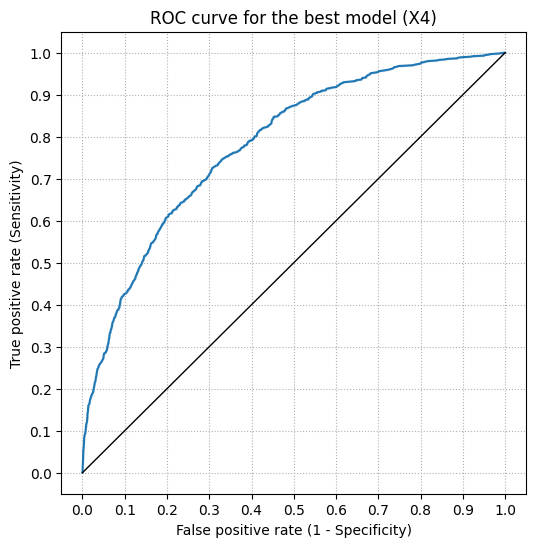

In [98]:
plt.figure(figsize = (6,6))
ax = sns.lineplot(
    data = df_,
    x = fpr, 
    y = tpr)
ax.set_title('ROC curve for the best model (X4)')
ax.set_xlabel("False positive rate (1 - Specificity)"), 
ax.set_ylabel("True positive rate (Sensitivity)")
ax.set_xticks([x/10 for x in range(0,11,1)])
ax.set_yticks([x/10 for x in range(0,11,1)])
ax.plot(df_.fpr, df_.fpr, color = 'k', linewidth = 1)
ax.grid(True, linestyle=':');

**Confusion table with different tresholds**

**Default**: 0.5 is used as threshold to convert probabilities to binary classes. The `predict` method uses 0.5 as threshold to split positives and negatives.

In [99]:
logit_class_prediction = best_model.predict(best_model_X_holdout)

In [100]:
logit_class_prediction

array([0, 0, 0, ..., 0, 0, 0])

In [101]:
values, counts = np.unique(logit_class_prediction.tolist(), return_counts=True)

In [102]:
values

array([0, 1])

In [103]:
counts

array([3442,  365])

In [104]:
print(values[0],' (no default): ',counts[0])
print(values[1],' (default): ',counts[1])

0  (no default):  3442
1  (default):  365


confusion matrix: summarize different type of errors and successfully predicted cases   
positive = "yes": explicitly specify the positive case

In [105]:
cm_object1 = confusion_matrix(y_holdout, logit_class_prediction, labels=[0,1])
cm1 = pd.DataFrame(cm_object1, 
    index=['Actual no default', 'Actual default'], 
    columns=['Predicted no default', 'Predicted default'])
cm1

,Predicted no default,Predicted default
Actual no default,2868,149
Actual default,574,216


Applying **different thresholds**

- 0.5 same as before

In [106]:
holdout_prediction = np.where(logit_predicted_probabilities_holdout < 0.5, 0, 1)
cm_object1b = confusion_matrix(y_holdout, holdout_prediction, labels=[0,1])
cm1b = pd.DataFrame(cm_object1b, 
    index=['Actual no default', 'Actual default'], 
    columns=['Predicted no default', 'Predicted default'])
cm1b

,Predicted no default,Predicted default
Actual no default,2868,149
Actual default,574,216


In [107]:
print(f'TPR: {round(cm1b.iloc[1,1] / cm1b.iloc[1].sum(), 3)}')
print(f'FPR: {round(cm1b.iloc[0,1] / cm1b.iloc[0].sum(), 3)}')

TPR: 0.273
FPR: 0.049


In [108]:
216/(216+574)

0.27341772151898736

- a sensible choice: **mean of predicted probabilities**

In [109]:
mean_predicted_default_prob = np.mean(logit_predicted_probabilities_holdout)
round(mean_predicted_default_prob, 3)

0.209

In [110]:
holdout_prediction = np.where(logit_predicted_probabilities_holdout < mean_predicted_default_prob, 0, 1)
cm_object2 = confusion_matrix(y_holdout, holdout_prediction, labels=[0,1])
cm2 = pd.DataFrame(cm_object2, 
    index=['Actul no defaul', 'Actual default'], 
    columns=['Predicted no default', 'Predicted default'])
cm2

,Predicted no default,Predicted default
Actul no defaul,2175,842
Actual default,249,541


In [111]:
print(f'TPR: {round(cm2.iloc[1,1] / cm2.iloc[1].sum(), 3)}')
print(f'FPR: {round(cm2.iloc[0,1] / cm2.iloc[0].sum(), 3)}')

TPR: 0.685
FPR: 0.279


### AUC using a loss function

**Loss function**: relative cost of of a false negative classification (as compared with a false positive classification)

In [112]:
FP = 1
FN = 10
cost = FN/FP

# the prevalence, or the proportion of cases in the population (n.cases/(n.controls+n.cases))
prevelance = y_train.sum()/len(y_train)
print(f'Prevelance: {prevelance:,.3f}')
print(f'Simple best threshold estimation: {FP/(FP+FN):,.3f}.')

Prevelance: 0.201
Simple best threshold estimation: 0.091.


**Draw ROC Curve and find optimal threshold with loss function**

Instread of with the simple threshold calculation we are running a search to find the thresholds where the loss is the smallest for each model for every fold. 

The optimal cut-off is the threshold that *maximizes the distance to the identity (diagonal) line*.

In [113]:
for i, v in enumerate(logit_models):
    print(i, v)

0 X1
1 X2
2 X3
3 X4
4 X5
5 LASSO


In [114]:
k = KFold(n_splits = 5, shuffle = True, random_state = 20250224)

In [115]:
best_thresholds_cv = dict()
expected_loss_cv = dict()
fold5_threshold = dict()
fold5_expected_loss = dict()
fold5_all_coords = dict()

for i, model_name in enumerate(logit_models):
    best_thresholds = []
    expected_loss =[]
    
    if model_name != 'LASSO':
        X = logit_model_vars[i]
        c_index = 0
    else:
        X = normalized_logitvars
        c_index = best_lambda_i
    
    fold = 0
    
    for train_index, test_index in k.split(X):
        X_fold = X.iloc[test_index,:]
        y_fold = y_train.iloc[test_index]
        
        pred_fold = generate_fold_prediction(logit_models[model_name], X_fold, fold, c_index)
    
        false_pos_rate, true_pos_rate, thresholds = roc_curve(y_fold, pred_fold)

        # this is where we pick the best threshold for minimal loss at each model for every single fold
        optimal_threshold = sorted(
            list(
                zip(
                    np.abs(
                        true_pos_rate + (1 - prevelance)/(cost * prevelance)*(1-false_pos_rate)
                    ),
                    thresholds
                )
            )
            , key=lambda i: i[0], reverse=True)[0][1]
        
        best_thresholds.append(optimal_threshold)
        threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
        
        tn, fp, fn, tp = confusion_matrix(y_fold, threshold_prediction, labels=[0,1]).ravel()

        # expected loss for each model for every single fold
        curr_exp_loss = (fp*FP + fn*FN)/len(y_fold)
        expected_loss.append(curr_exp_loss)
        fold = fold+1

    # best threshold and expected loss for each model (averaging out the folds)
    best_thresholds_cv[model_name] = np.mean(best_thresholds)
    expected_loss_cv[model_name] = np.mean(expected_loss)

    # best threshold and expected loss for each model for fold5 ONLY
    fold5_threshold[model_name] = optimal_threshold
    fold5_expected_loss[model_name] = curr_exp_loss

    all_coords = pd.DataFrame({
        'false_pos': false_pos_rate*sum(y_fold == 0),
        'true_pos': true_pos_rate*sum(y_fold == 1),
        'false_neg': sum(y_fold == 1) - true_pos_rate*sum(y_fold == 1),
        'true_neg': sum(y_fold == 0) - false_pos_rate*sum(y_fold == 0),
        'pos': sum(y_fold == 1),
        'neg': sum(y_fold == 0),
        'n': len(y_fold),
        'thresholds': thresholds
    })
    
    fold5_all_coords[model_name] = all_coords

In [116]:
fold5_all_coords['X1']

,false_pos,true_pos,false_neg,true_neg,pos,neg,n,thresholds
0,0.0,0.0,622.0,2423.0,622,2423,3045,inf
1,0.0,1.0,621.0,2423.0,622,2423,3045,0.745738
2,0.0,5.0,617.0,2423.0,622,2423,3045,0.730024
3,1.0,5.0,617.0,2422.0,622,2423,3045,0.718177
4,1.0,6.0,616.0,2422.0,622,2423,3045,0.716130
...,...,...,...,...,...,...,...,...
865,2354.0,620.0,2.0,69.0,622,2423,3045,0.027841
866,2354.0,621.0,1.0,69.0,622,2423,3045,0.027838
867,2372.0,621.0,1.0,51.0,622,2423,3045,0.025744
868,2372.0,622.0,0.0,51.0,622,2423,3045,0.025385


In [117]:
logit_summary2 = pd.DataFrame(best_thresholds_cv.items(),columns=['Model', 'Avg of optimal thresholds'])
logit_summary2['Threshold for Fold5'] = fold5_threshold.values()
logit_summary2['Avg expected loss'] = expected_loss_cv.values()
logit_summary2['Expected loss for Fold5'] = fold5_expected_loss.values()

In [118]:
logit_summary2

,Model,Avg of optimal thresholds,Threshold for Fold5,Avg expected loss,Expected loss for Fold5
0,X1,0.088968,0.109705,0.728805,0.701478
1,X2,0.094622,0.135837,0.658219,0.671593
2,X3,0.079089,0.070868,0.632478,0.632841
3,X4,0.087955,0.075800,0.619345,0.621018
4,X5,0.090776,0.096778,0.624402,0.635468
5,LASSO,0.084651,0.067098,0.627620,0.644992


### Loss plot based on Fold5 in CV

In [ ]:
model_to_plot = 'X1'

In [ ]:
fold5_all_coords[model_to_plot]

In [ ]:
fold5_threshold[model_to_plot]

In [ ]:
fold5_expected_loss[model_to_plot]

In [ ]:
create_loss_plot(
    fold5_all_coords[model_to_plot], 
    fold5_threshold[model_to_plot], 
    fold5_expected_loss[model_to_plot]);

#### ROC plot plot based on Fold5 in CV

In [ ]:
model_to_plot = 'X1'
create_roc_plot_with_optimal(fold5_all_coords[model_to_plot], fold5_threshold[model_to_plot]);

#### Pick best model based on average expected loss

### X4

In [ ]:
best_logit_optimal_treshold = best_thresholds_cv["X4"]
best_logit_optimal_treshold

**Get expected loss on holdout**

In [ ]:
holdout_treshold = np.where(logit_predicted_probabilities_holdout < best_logit_optimal_treshold, 0, 1)
tn, fp, fn, tp = confusion_matrix(y_holdout, holdout_treshold, labels=[0,1]).ravel()
expected_loss_holdout = (fp*FP + fn*FN)/len(y_holdout)
round(expected_loss_holdout, 3)

In [ ]:
cm_object3 = confusion_matrix(y_holdout, holdout_treshold, labels=[0,1])
cm3 = pd.DataFrame(cm_object3, 
    index=['Actul no defaul', 'Actual default'], 
    columns=['Predicted no default', 'Predicted default'])
cm3

In [ ]:
print(f'TPR: {round(cm3.iloc[1,1] / cm3.iloc[1].sum(), 3)}')
print(f'FPR: {round(cm3.iloc[0,1] / cm3.iloc[0].sum(), 3)}')

### Prediction with random forest 

In [ ]:
rfvars_train = rfvars.iloc[index_train]
rfvars_holdout = rfvars.iloc[index_holdout]

In [ ]:
rfvars_train.columns

### Probability forest

A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting. The sub-sample size is controlled with the `max_samples` parameter if `bootstrap = True` (default), otherwise the whole dataset is used to build each tree.
- `max_features`: number of features to consider when looking for the best split
- `min_samples_fit`: the minimum number of samples required`to split an internal node

In [ ]:
grid = {'max_features': [5, 6, 7],
        'criterion':['gini'],
        'min_samples_split': [11, 16]}

In [ ]:
prob_forest = RandomForestClassifier(
    random_state=20250224, 
    n_estimators=50, # this should be higher, but it is kept low in order to control runtime on class
    oob_score=True)

prob_forest_grid = GridSearchCV(
    prob_forest, 
    grid, 
    cv = 5, 
    refit='accuracy', # Refit an estimator using the best found parameters on the whole dataset.
                      # For multiple metric evaluation, this needs to be a str denoting the scorer 
                      # that would be used to find the best parameters for refitting the estimator at the end.
    scoring = ['accuracy', 'roc_auc', 'neg_brier_score'], 
    n_jobs=-1)

In [ ]:
%%time
prob_forest_fit = prob_forest_grid.fit(rfvars_train, y_train)

**CV summary table**

In [ ]:
prob_forest_fit.cv_results_

Our grid has 3x2=6 elements. 

In [ ]:
cv_accuracy = np.zeros([6])
for i in range(5):
    cv_accuracy = cv_accuracy + prob_forest_fit.cv_results_['split' + str(i) + '_test_accuracy']
cv_accuracy = cv_accuracy/5
cv_accuracy

In [ ]:
np.max(cv_accuracy)

In [ ]:
prob_forest_fit.best_score_

In [ ]:
cv_auc = np.zeros([6])
for i in range(5):
    cv_auc = cv_auc + prob_forest_fit.cv_results_['split' + str(i) + '_test_roc_auc']
cv_auc = cv_auc/5
cv_auc

In [ ]:
cv_rmse = np.zeros([6])
for i in range(5):
    cv_rmse = cv_rmse +np.sqrt(-1*(prob_forest_fit.cv_results_['split' + str(i) + '_test_neg_brier_score'])).tolist()
cv_rmse = cv_rmse/5
cv_rmse

In [ ]:
prob_forest_cv_results = pd.DataFrame({
    'max_features': prob_forest_fit.cv_results_['param_max_features'],
    'min_samples_split': prob_forest_fit.cv_results_['param_min_samples_split'],
    'cv_accuracy': cv_accuracy,
    'cv_auc': cv_auc,
    'cv_rmse': cv_rmse
})

In [ ]:
prob_forest_cv_results.style.format(
    {
        'cv_accuracy': '{:.5f}',
        'cv_auc': '{:.5f}',
        'cv_rmse': '{:.5f}'
    }
)

**Optimal parameter values**

In [ ]:
best_max_features = prob_forest_fit.best_params_['max_features']
best_min_sample_split = prob_forest_fit.best_params_['min_samples_split']
prob_forest_fit.best_params_

**Average RMSE and AUC over folds**

In [ ]:
prob_forest_best_results = prob_forest_cv_results[
    (prob_forest_cv_results.max_features == best_max_features) & 
    (prob_forest_cv_results.min_samples_split == best_min_sample_split)]
prob_forest_best_results_index = prob_forest_best_results.index.values[0]

CV_RMSE['rf_p'] = prob_forest_best_results.cv_rmse.values[0]
CV_AUC['rf_p'] = prob_forest_best_results.cv_auc.values[0]

In [ ]:
CV_RMSE

In [ ]:
CV_AUC

**Get fold level RMSE and AUC**

In [ ]:
CV_RMSE_folds_rf_p = list()

for i in range(5):
    rmse = np.sqrt(-1*(prob_forest_fit.cv_results_['split' + str(i) + '_test_neg_brier_score'])).tolist()[prob_forest_best_results_index]
    CV_RMSE_folds_rf_p.append(rmse)

CV_RMSE_folds['rf_p'] = CV_RMSE_folds_rf_p

CV_AUC_folds_rf_p = list()

for i in range(5):
    rmse = prob_forest_fit.cv_results_['split' + str(i) + '_test_roc_auc'][prob_forest_best_results_index]
    CV_AUC_folds_rf_p.append(rmse)

CV_AUC_folds['rf_p'] = CV_AUC_folds_rf_p

In [ ]:
pd.DataFrame(CV_AUC_folds)

**Now use loss function and search for best thresholds and expected loss for each folds**

In [ ]:
best_thresholds = list()
expected_loss = list()

fold = 0
for train_index, test_index in k.split(rfvars_train):
    print(f'{datetime.datetime.now()}: fold {fold}...') 
    X_fold = rfvars_train.iloc[test_index,:]
    y_fold = y_train.iloc[test_index]
    
    X_fold_train = rfvars_train.iloc[train_index,:]
    y_fold_train = y_train.iloc[train_index]
    
    prob_forest_best = RandomForestClassifier(
        random_state=20250224, 
        n_estimators=50, # make it higher in practice (default being 100)
        oob_score=True,
        criterion = 'gini', 
        max_features = best_max_features, min_samples_split = best_min_sample_split
    )
    
    prob_forest_best_fold = prob_forest_best.fit(X_fold_train, y_fold_train)
    pred_fold = prob_forest_best_fold.predict_proba(X_fold)[:,1]

    false_pos_rate, true_pos_rate, threshold = roc_curve(y_fold, pred_fold)
    
    best_threshold = sorted(
        list(
            zip(
                np.abs(
                    true_pos_rate + (1 - prevelance)/(cost * prevelance)*(1-false_pos_rate)
                ),
                threshold
            )
        ), 
        key=lambda x: x[0], reverse=True)[0][1]
    
    best_thresholds.append(best_threshold)
    
    threshold_prediction = np.where(pred_fold < best_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(y_fold, threshold_prediction, labels=[0,1]).ravel()
    curr_exp_loss = (fp*FP + fn*FN)/len(y_fold)
    expected_loss.append(curr_exp_loss)
    fold += 1

In [ ]:
for f, t in enumerate(best_thresholds):
    print(f'Fold: {f}, best threshold: {t:,.4f}.')

In [ ]:
for f, l in enumerate(expected_loss):
    print(f'Fold: {f}, smalles loss: {l:,.4f}.')

In [ ]:
fold5_threshold_rf = best_threshold
fold5_expected_loss_rf = curr_exp_loss

all_coords_rf = pd.DataFrame({
    'false_pos': false_pos_rate*sum(y_fold == 0),
    'true_pos': true_pos_rate*sum(y_fold == 1),
    'false_neg': sum(y_fold == 1) - true_pos_rate*sum(y_fold == 1),
    'true_neg': sum(y_fold == 0) - false_pos_rate*sum(y_fold == 0),
    'pos': sum(y_fold == 1),
    'neg': sum(y_fold == 0),
    'n': len(y_fold),
    'thresholds': threshold
})

all_coords_rf

In [ ]:
expected_loss_cv['rf_p'] = np.mean(expected_loss)
best_thresholds_cv['rf_p'] = np.mean(best_thresholds)

In [ ]:
rf_summary = pd.DataFrame(
    {'CV RMSE': [round(CV_RMSE['rf_p'], 3)],
     'CV AUC': [round(CV_AUC['rf_p'], 3)],
     'Avg of optimal thresholds': [round(best_thresholds_cv['rf_p'], 3)],
     'Threshold for Fold5': [round(best_threshold, 3)],
     'Avg expected loss': [round(expected_loss_cv['rf_p'], 3)],
     'Expected loss for Fold5': [round(curr_exp_loss, 3)]})

rf_summary

**Plots based on Fold5 in CV**

In [ ]:
create_loss_plot(all_coords_rf, fold5_threshold_rf, fold5_expected_loss_rf);

In [ ]:
create_roc_plot_with_optimal(all_coords_rf, fold5_threshold_rf)

**Take model to holdout and estimate RMSE, AUC and expected loss**

In [ ]:
prob_forest_fit_best = prob_forest_fit.best_estimator_
rf_predicted_probabilities_holdout = prob_forest_fit_best.predict_proba(rfvars_holdout)[:,1]
rmse_rf = np.sqrt(mean_squared_error(y_holdout, rf_predicted_probabilities_holdout))
round(rmse_rf, 3)

**ROC AUC  on holdout**

In [ ]:
auc_rf = roc_auc_score(y_holdout, rf_predicted_probabilities_holdout)
round(auc_rf, 3)

**Expected loss on holdout**

In [ ]:
holdout_treshold = np.where(rf_predicted_probabilities_holdout < best_thresholds_cv['rf_p'], 0, 1)
tn, fp, fn, tp = confusion_matrix(y_holdout, holdout_treshold, labels=[0,1]).ravel()
expected_loss_holdout = (fp*FP + fn*FN)/len(y_holdout)
round(expected_loss_holdout, 3)

In [ ]:
import datetime
print(datetime.datetime.now())

### Getting probalbilities and classifications from RandomforestClassifier

- classes

In [ ]:
prob_forest_best_fold.predict(rfvars_holdout)

- probabilities

In [ ]:
prob_forest_best_fold.predict_proba(rfvars_holdout)

## Final results

In [ ]:
nvars['rf_p'] = len(rfvars.columns)

In [ ]:
summary_results = pd.DataFrame({"Model": list(nvars.keys()),
                              "Number of predictors": list(nvars.values()),
                              "CV RMSE": list(CV_RMSE.values()),
                              "CV AUC": list(CV_AUC.values()),
                              "CV threshold": list(best_thresholds_cv.values()),
                              "CV expected Loss": list(expected_loss_cv.values())
                               })

In [ ]:
summary_results.style.format(
    {
        'CV threshold': '{:.4f}',
        'CV AUC': '{:.4f}',
        'CV RMSE': '{:.4f}',
        'CV expected Loss': '{:.4f}'
    }
)